# Quiz Performance Analysis



**Structure:**
1. Imports
2. Load data
3. Data overview
4. Merge into analysis tables
5. Feature engineering (score %, dates, completion flag)
6. Data cleaning & validation
7. Performance analysis
8. Per-student weak-subcategory analysis

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Data



In [3]:
users = pd.read_csv(r"C:\Users\USER\OneDrive\Документы\users.csv")
categories = pd.read_csv(r"C:\Users\USER\OneDrive\Документы\categories.csv")
subcategories = pd.read_csv(r"C:\Users\USER\OneDrive\Документы\subcategories.csv")
allowed_topics = pd.read_csv(r"C:\Users\USER\OneDrive\Документы\allowed_topics.csv")
quizzes = pd.read_csv(r"C:\Users\USER\OneDrive\Документы\quizzes.csv")
user_answers = pd.read_csv(r"C:\Users\USER\OneDrive\Документы\user_answers.csv")
user_subcategory_points = pd.read_csv(r"C:\Users\USER\OneDrive\Документы\user_subcategory_points.csv")
users.head()

,id,name,email,age,gender
0,1,Ahmed,ahmed1@example.com,15,male
1,2,Mohamed,mohamed2@example.com,14,male
2,3,Sara,sara3@example.com,18,female
3,4,Nour,nour4@example.com,17,female
4,5,Yousef,yousef5@example.com,17,male


## 3. Data Overview

Quick look at the shape and columns of every raw table before doing any joins, so we know what we're working with (and can spot obviously missing columns early).

In [4]:
raw_tables = {
    "users": users,
    "categories": categories,
    "subcategories": subcategories,
    "allowed_topics": allowed_topics,
    "quizzes": quizzes,
    "user_answers": user_answers,
    "user_subcategory_points": user_subcategory_points,
}

for name, df in raw_tables.items():
    print(f"{name}: shape={df.shape}")
    print(df.columns.tolist())
    print("-" * 60)

users: shape=(40, 5)
['id', 'name', 'email', 'age', 'gender']
------------------------------------------------------------
categories: shape=(4, 2)
['id', 'name']
------------------------------------------------------------
subcategories: shape=(8, 3)
['id', 'name', 'category_id']
------------------------------------------------------------
allowed_topics: shape=(20, 3)
['id', 'subcategory_id', 'topic_name']
------------------------------------------------------------
quizzes: shape=(344, 9)
['id', 'user_id', 'subcategory_id', 'difficulty', 'score', 'total_questions', 'included_in_recommendation_batch', 'created_at', 'finished_at']
------------------------------------------------------------
user_answers: shape=(2935, 7)
['id', 'user_id', 'quiz_id', 'question_id', 'selected_answer', 'is_correct', 'answered_at']
------------------------------------------------------------
user_subcategory_points: shape=(91, 4)
['id', 'user_id', 'subcategory_id', 'total_points']
-------------------------

In [5]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      40 non-null     int64
 1   name    40 non-null     str  
 2   email   40 non-null     str  
 3   age     40 non-null     int64
 4   gender  40 non-null     str  
dtypes: int64(2), str(3)
memory usage: 1.7 KB


## 4. Merge Into Analysis Tables



### 4.1 quiz_df — quizzes + users + subcategories + categories

In [6]:
quiz_df = quizzes.merge(
    users,
    left_on="user_id",
    right_on="id",
    how="left",
    suffixes=("_quiz", "_user"),
)

quiz_df = quiz_df.merge(
    subcategories,
    left_on="subcategory_id",
    right_on="id",
    how="left",
    suffixes=("", "_subcategory"),
)

quiz_df = quiz_df.merge(
    categories,
    left_on="category_id",
    right_on="id",
    how="left",
    suffixes=("", "_category"),
)

print("Shape:", quiz_df.shape)
print("Columns:", quiz_df.columns.tolist())
quiz_df.head()

Shape: (344, 19)
Columns: ['id_quiz', 'user_id', 'subcategory_id', 'difficulty', 'score', 'total_questions', 'included_in_recommendation_batch', 'created_at', 'finished_at', 'id_user', 'name', 'email', 'age', 'gender', 'id', 'name_subcategory', 'category_id', 'id_category', 'name_category']


,id_quiz,user_id,subcategory_id,difficulty,score,total_questions,included_in_recommendation_batch,created_at,finished_at,id_user,name,email,age,gender,id,name_subcategory,category_id,id_category,name_category
0,1,1,1,3,7,15,1,2026-06-16 18:00:00,2026-06-16 18:30:00,1,Ahmed,ahmed1@example.com,15,male,1,Python,1,1,Programming
1,2,1,1,3,0,5,0,2026-07-04 03:00:00,NaN,1,Ahmed,ahmed1@example.com,15,male,1,Python,1,1,Programming
2,3,1,1,3,9,15,0,2026-07-17 06:00:00,2026-07-17 06:30:00,1,Ahmed,ahmed1@example.com,15,male,1,Python,1,1,Programming
3,4,1,2,1,4,5,1,2026-05-25 17:00:00,2026-05-25 17:10:00,1,Ahmed,ahmed1@example.com,15,male,2,JavaScript,1,1,Programming
4,5,1,5,2,5,10,0,2026-06-06 13:00:00,2026-06-06 13:20:00,1,Ahmed,ahmed1@example.com,15,male,5,Geometry,2,2,Mathematics


### 4.2 answer_df — answers + users + quiz info

In [7]:
answer_df = user_answers.merge(
    users,
    left_on="user_id",
    right_on="id",
    how="left",
    suffixes=("_answer", "_user"),
)

answer_df = answer_df.merge(
    quizzes[["id", "subcategory_id", "difficulty", "created_at"]],
    left_on="quiz_id",
    right_on="id",
    how="left",
    suffixes=("", "_quiz"),
)

print("Shape:", answer_df.shape)
print("Columns:", answer_df.columns.tolist())
answer_df.head()

Shape: (2935, 16)
Columns: ['id_answer', 'user_id', 'quiz_id', 'question_id', 'selected_answer', 'is_correct', 'answered_at', 'id_user', 'name', 'email', 'age', 'gender', 'id', 'subcategory_id', 'difficulty', 'created_at']


,id_answer,user_id,quiz_id,question_id,selected_answer,is_correct,answered_at,id_user,name,email,age,gender,id,subcategory_id,difficulty,created_at
0,1,1,1,41,b,1,2026-06-16 18:10:00,1,Ahmed,ahmed1@example.com,15,male,1,1,3,2026-06-16 18:00:00
1,2,1,1,326,c,0,2026-06-16 18:15:00,1,Ahmed,ahmed1@example.com,15,male,1,1,3,2026-06-16 18:00:00
2,3,1,1,360,a,1,2026-06-16 18:09:00,1,Ahmed,ahmed1@example.com,15,male,1,1,3,2026-06-16 18:00:00
3,4,1,1,84,d,0,2026-06-16 18:08:00,1,Ahmed,ahmed1@example.com,15,male,1,1,3,2026-06-16 18:00:00
4,5,1,1,113,c,1,2026-06-16 18:18:00,1,Ahmed,ahmed1@example.com,15,male,1,1,3,2026-06-16 18:00:00


## 5. Feature Engineering

Derive the fields we'll actually analyze: score as a percentage, proper datetime types, and a boolean flag for whether a quiz was completed.

### 5.1 Score percentage (quiz_df)

In [8]:
# score as a % of total questions, easier to compare across quizzes of different length
quiz_df["score_percentage"] = (quiz_df["score"] / quiz_df["total_questions"]) * 100

quiz_df[["user_id", "subcategory_id", "name", "difficulty", "score", "total_questions", "score_percentage"]].head()

,user_id,subcategory_id,name,difficulty,score,total_questions,score_percentage
0,1,1,Ahmed,3,7,15,46.666667
1,1,1,Ahmed,3,0,5,0.000000
2,1,1,Ahmed,3,9,15,60.000000
3,1,2,Ahmed,1,4,5,80.000000
4,1,5,Ahmed,2,5,10,50.000000


### 5.2 Datetime conversion

In [9]:
# quiz_df: when the quiz was started/finished
quiz_df["created_at"] = pd.to_datetime(quiz_df["created_at"], errors="coerce")
quiz_df["finished_at"] = pd.to_datetime(quiz_df["finished_at"], errors="coerce")

# answer_df: when each answer was submitted / when its quiz was created
answer_df["answered_at"] = pd.to_datetime(answer_df["answered_at"], errors="coerce")
answer_df["created_at"] = pd.to_datetime(answer_df["created_at"], errors="coerce")

print(quiz_df[["created_at", "finished_at"]].dtypes)
print(answer_df[["answered_at", "created_at"]].dtypes)

created_at     datetime64[us]
finished_at    datetime64[us]
dtype: object
answered_at    datetime64[us]
created_at     datetime64[us]
dtype: object


### 5.3 Completion flag

In [10]:
# a quiz counts as "completed" if it has a finished_at timestamp
quiz_df["is_completed"] = quiz_df["finished_at"].notna()

quiz_df["is_completed"].value_counts()

is_completed
True     294
False     50
Name: count, dtype: int64

## 6. Data Cleaning & Validation

Sanity checks on the merged tables: missing values, duplicates, dtypes, unfinished quizzes, invalid scores, and the allowed set of difficulty values.

### 6.1 Missing values

In [11]:
print("quiz_df — missing values")
print(quiz_df.isnull().sum())

print("\nanswer_df — missing values")
print(answer_df.isnull().sum())

quiz_df — missing values
id_quiz                              0
user_id                              0
subcategory_id                       0
difficulty                           0
score                                0
total_questions                      0
included_in_recommendation_batch     0
created_at                           0
finished_at                         50
id_user                              0
name                                 0
email                                0
age                                  0
gender                               0
id                                   0
name_subcategory                     0
category_id                          0
id_category                          0
name_category                        0
score_percentage                     0
is_completed                         0
dtype: int64

answer_df — missing values
id_answer          0
user_id            0
quiz_id            0
question_id        0
selected_answer    0
is_correct

### 6.2 Duplicate rows

In [12]:
print("quiz_df duplicates:", quiz_df.duplicated().sum())
print("answer_df duplicates:", answer_df.duplicated().sum())

quiz_df duplicates: 0
answer_df duplicates: 0


### 6.3 Data types

In [13]:
print("quiz_df dtypes")
print(quiz_df.dtypes)

print("\nanswer_df dtypes")
print(answer_df.dtypes)

quiz_df dtypes
id_quiz                                      int64
user_id                                      int64
subcategory_id                               int64
difficulty                                   int64
score                                        int64
total_questions                              int64
included_in_recommendation_batch             int64
created_at                          datetime64[us]
finished_at                         datetime64[us]
id_user                                      int64
name                                           str
email                                          str
age                                          int64
gender                                         str
id                                           int64
name_subcategory                               str
category_id                                  int64
id_category                                  int64
name_category                                  str
score_percentage

### 6.4 Unfinished quizzes

Quizzes with no finished_at timestamp — these will be excluded from performance analysis.

In [14]:
unfinished_quizzes = quiz_df[quiz_df["finished_at"].isna()]

print("Unfinished quizzes:", len(unfinished_quizzes))
unfinished_quizzes[["user_id", "id_quiz", "score", "total_questions", "created_at", "finished_at"]].head(20)

Unfinished quizzes: 50


,user_id,id_quiz,score,total_questions,created_at,finished_at
1,1,2,0,5,2026-07-04 03:00:00,NaT
6,1,7,0,5,2026-06-15 17:00:00,NaT
7,1,8,0,15,2026-05-20 07:00:00,NaT
8,1,9,0,5,2026-05-23 23:00:00,NaT
19,2,20,0,10,2026-07-21 15:00:00,NaT
21,3,22,0,10,2026-05-16 00:00:00,NaT
28,3,29,0,15,2026-05-08 18:00:00,NaT
31,4,32,0,15,2026-06-28 22:00:00,NaT
33,4,34,0,15,2026-07-22 20:00:00,NaT
35,4,36,0,10,2026-08-01 21:00:00,NaT


### 6.5 Score validity

Flag any quiz where the score is negative or exceeds the total number of questions — these would indicate a data issue rather than real performance.

In [15]:
invalid_scores = quiz_df[
    (quiz_df["score"] < 0) | (quiz_df["score"] > quiz_df["total_questions"])
]

print("Invalid scores:", len(invalid_scores))
invalid_scores

Invalid scores: 0


,id_quiz,user_id,subcategory_id,difficulty,score,total_questions,included_in_recommendation_batch,created_at,finished_at,id_user,...,email,age,gender,id,name_subcategory,category_id,id_category,name_category,score_percentage,is_completed


### 6.6 Difficulty values

Confirm difficulty only contains the values we expect (catches typos/unexpected categories).

In [16]:
print("Difficulty values:", sorted(quiz_df["difficulty"].unique()))

Difficulty values: [np.int64(1), np.int64(2), np.int64(3)]


## 7. Performance Analysis

From here on we only look at **completed** quizzes, since unfinished quizzes don't have a meaningful final score.

### 7.1 Completion rate

In [17]:
completion_rate = quiz_df["is_completed"].mean() * 100
print(f"Quiz completion rate: {completion_rate:.2f}%")

# using a count-based version instead of .mean() for clarity:
completed_count = quiz_df["is_completed"].sum()
total_count = len(quiz_df)
print(f"{completed_count} / {total_count} quizzes completed")

Quiz completion rate: 85.47%
294 / 344 quizzes completed


In [18]:
# from here on, work only with completed quizzes
completed_quiz_df = quiz_df[quiz_df["is_completed"]].copy()
print("Completed quizzes:", len(completed_quiz_df))

Completed quizzes: 294


### 7.2 Overall performance

In [19]:
print("Average Score:", completed_quiz_df["score_percentage"].mean())
print("Median Score:", completed_quiz_df["score_percentage"].median())
print("Minimum Score:", completed_quiz_df["score_percentage"].min())
print("Maximum Score:", completed_quiz_df["score_percentage"].max())

Average Score: 64.62585034013605
Median Score: 60.0
Minimum Score: 0.0
Maximum Score: 100.0


### 7.3 Score distribution

In [20]:
completed_quiz_df["score_percentage"].describe()

count    294.000000
mean      64.625850
std       16.980879
min        0.000000
25%       55.000000
50%       60.000000
75%       80.000000
max      100.000000
Name: score_percentage, dtype: float64

### 7.4 Performance by difficulty

In [21]:
difficulty_performance = (
    completed_quiz_df
    .groupby("difficulty")["score_percentage"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

difficulty_performance

,difficulty,count,mean,median
0,1,96,66.944444,66.666667
1,2,103,61.391586,60.000000
2,3,95,65.789474,66.666667


### 7.5 Performance by category

In [22]:
category_performance = (
    completed_quiz_df
    .groupby("name_category")["score_percentage"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
    .reset_index()
)

category_performance

,name_category,count,mean,median
0,Programming,83,63.453815,60.000000
1,Science,90,63.740741,60.000000
2,Mathematics,66,65.454545,66.666667
3,Languages,55,66.848485,66.666667


### 7.6 Performance by subcategory

In [23]:
subcategory_performance = (
    completed_quiz_df
    .groupby("name_subcategory")["score_percentage"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
    .reset_index()
)

subcategory_performance

,name_subcategory,count,mean,median
0,Physics,40,61.416667,60.000000
1,Python,31,62.795699,60.000000
2,Databases,25,62.800000,60.000000
3,Geometry,42,64.523810,60.000000
4,JavaScript,27,64.814815,66.666667
5,Biology,50,65.600000,60.000000
6,English Grammar,55,66.848485,66.666667
7,Algebra,24,67.083333,70.000000


## 8. Per-Student Weak Subcategories

**Question:** for each student, which subcategories are they weakest in?

In [24]:
student_subcategory_performance = (
    completed_quiz_df
    .groupby(["user_id", "name_subcategory"])
    .agg(
        quizzes_count=("id_quiz", "count"),
        average_score=("score_percentage", "mean"),
    )
    .reset_index()
)

# sort so that, within each student, weakest subcategories come first
student_subcategory_performance = student_subcategory_performance.sort_values(
    ["user_id", "average_score"]
)

student_subcategory_performance.head(20)

,user_id,name_subcategory,quizzes_count,average_score
0,1,Algebra,1,40.000000
3,1,Python,2,53.333333
1,1,Geometry,5,60.666667
2,1,JavaScript,2,70.000000
4,2,Biology,1,40.000000
5,2,Databases,2,53.333333
7,2,JavaScript,1,60.000000
6,2,Geometry,1,70.000000
8,3,Biology,2,65.000000
9,3,Databases,1,66.666667


### Look up a single student

Change `student_id` below to inspect any individual student's weakest subcategories.

In [25]:
student_id = 1

student_subcategory_performance[
    student_subcategory_performance["user_id"] == student_id
]

,user_id,name_subcategory,quizzes_count,average_score
0,1,Algebra,1,40.000000
3,1,Python,2,53.333333
1,1,Geometry,5,60.666667
2,1,JavaScript,2,70.000000


# Visualization

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

 Q: How are quiz scores distributed — are most students doing fine, or is there a cluster struggling?

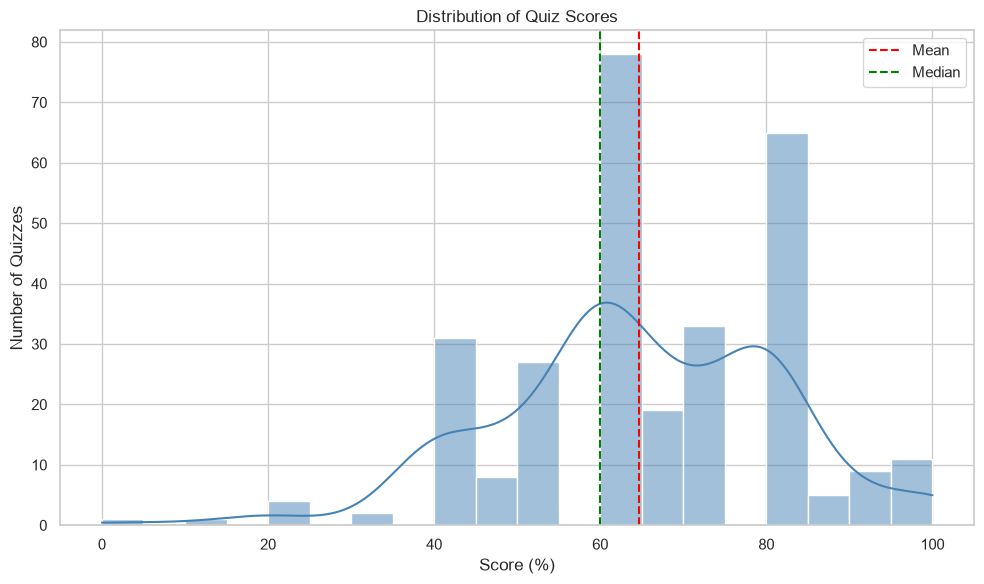

In [27]:
plt.figure()
sns.histplot(completed_quiz_df["score_percentage"], bins=20, kde=True, color="steelblue")
plt.axvline(completed_quiz_df["score_percentage"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(completed_quiz_df["score_percentage"].median(), color="green", linestyle="--", label="Median")
plt.title("Distribution of Quiz Scores")
plt.xlabel("Score (%)")
plt.ylabel("Number of Quizzes")
plt.legend()
plt.tight_layout()
plt.show()

Q: Does quiz difficulty actually affect performance?

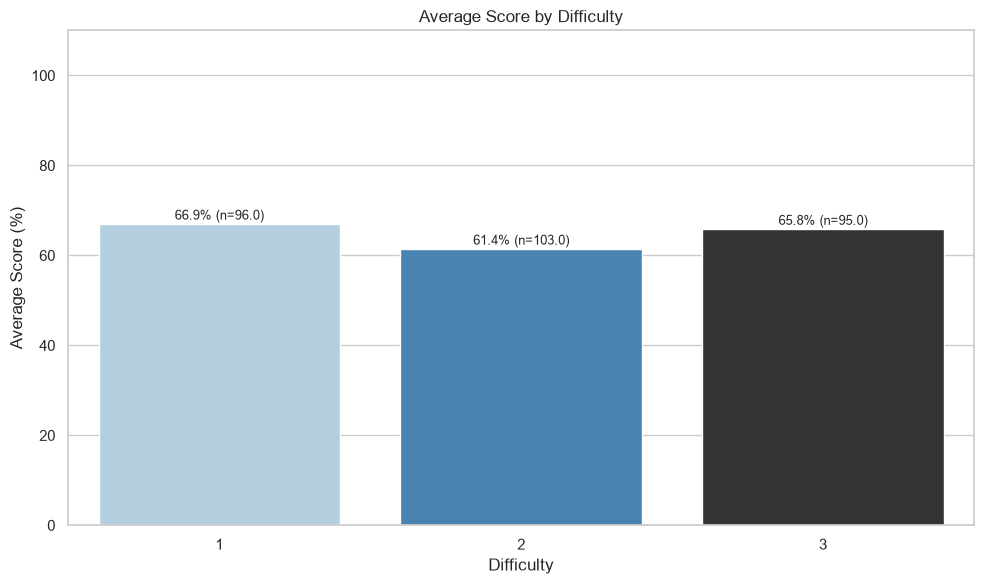

In [28]:
plt.figure()
ax = sns.barplot(
    data=difficulty_performance,
    x="difficulty", y="mean",
    hue="difficulty", legend=False,
    palette="Blues_d"
)
for i, row in difficulty_performance.iterrows():
    ax.text(i, row["mean"] + 1, f'{row["mean"]:.1f}% (n={row["count"]})',
            ha="center", fontsize=9)
plt.title("Average Score by Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Average Score (%)")
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

Q: Which categories are students weakest in overall?

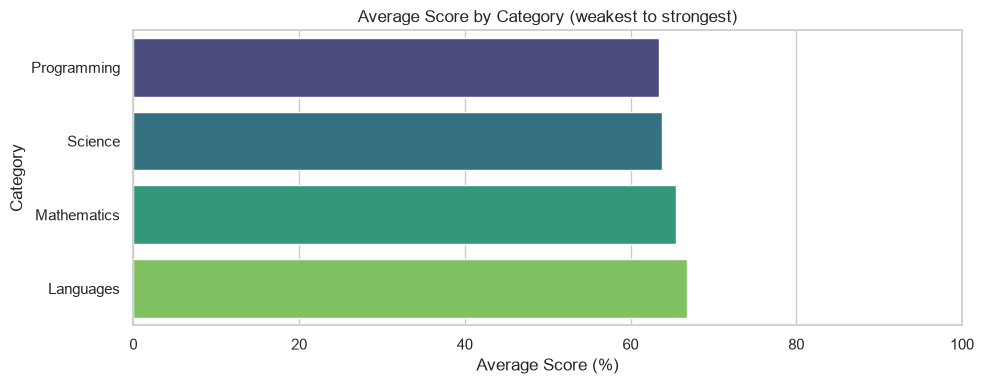

In [29]:
plt.figure(figsize=(10, max(4, 0.4 * len(category_performance))))
sns.barplot(
    data=category_performance,
    y="name_category", x="mean",
    hue="name_category", legend=False,
    palette="viridis"
)
plt.title("Average Score by Category (weakest to strongest)")
plt.xlabel("Average Score (%)")
plt.ylabel("Category")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

Q: Which specific subcategories need the most attention?

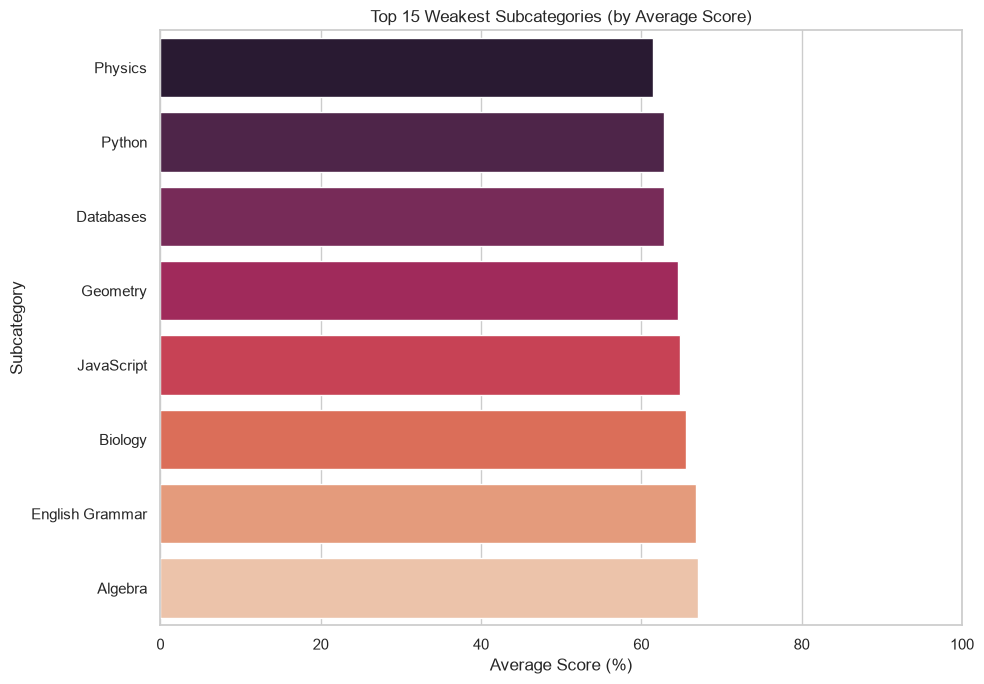

In [31]:
weakest_subcategories = subcategory_performance.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=weakest_subcategories,
    y="name_subcategory", x="mean",
    hue="name_subcategory", legend=False,
    palette="rocket"
)
plt.title("Top 15 Weakest Subcategories (by Average Score)")
plt.xlabel("Average Score (%)")
plt.ylabel("Subcategory")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

Q: What share of started quizzes actually get finished?

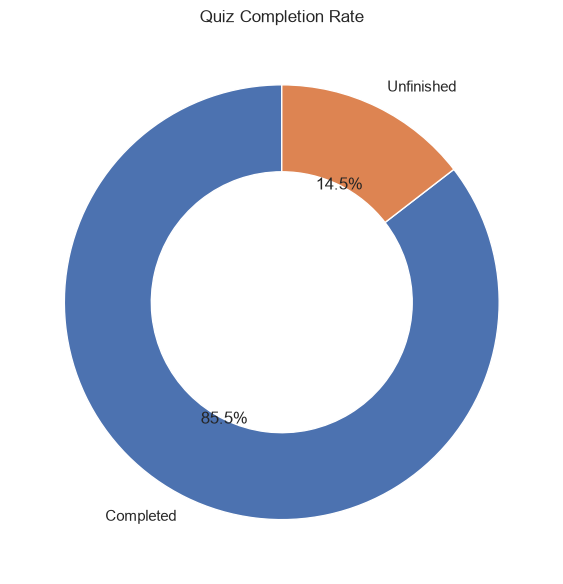

In [32]:
completion_counts = quiz_df["is_completed"].value_counts()
labels = ["Completed" if v else "Unfinished" for v in completion_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    completion_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
    wedgeprops={"width": 0.4}
)
plt.title("Quiz Completion Rate")
plt.tight_layout()
plt.show()

Q: Is average performance improving or declining over time?

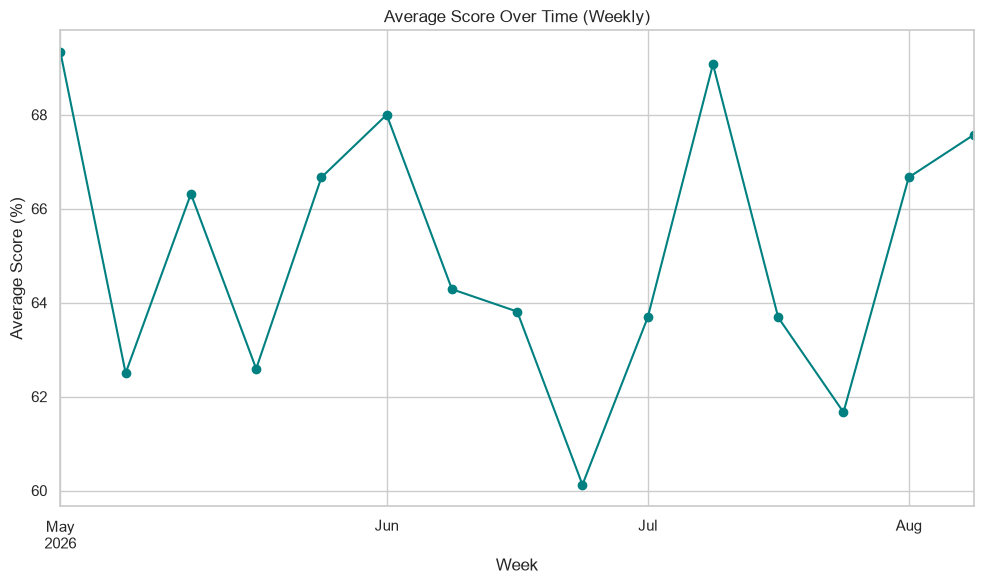

In [33]:
score_over_time = (
    completed_quiz_df
    .set_index("finished_at")
    .resample("W")["score_percentage"]
    .mean()
)

plt.figure()
score_over_time.plot(marker="o", color="teal")
plt.title("Average Score Over Time (Weekly)")
plt.xlabel("Week")
plt.ylabel("Average Score (%)")
plt.tight_layout()
plt.show()

Q: For the most active students, which subcategories are each of them individually weakest in?

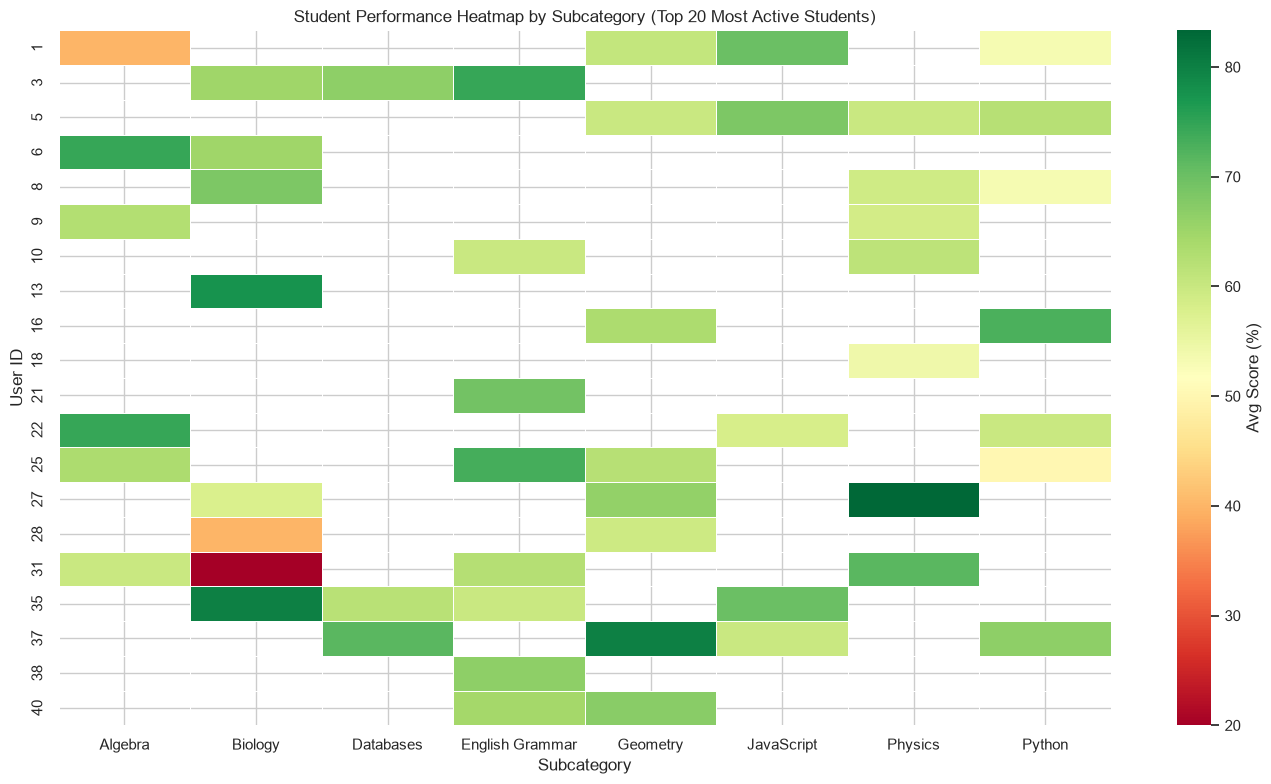

In [34]:
top_students = (
    completed_quiz_df["user_id"]
    .value_counts()
    .head(20)
    .index
)

heatmap_data = (
    student_subcategory_performance[
        student_subcategory_performance["user_id"].isin(top_students)
    ]
    .pivot(index="user_id", columns="name_subcategory", values="average_score")
)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="RdYlGn", annot=False, linewidths=0.5, cbar_kws={"label": "Avg Score (%)"})
plt.title("Student Performance Heatmap by Subcategory (Top 20 Most Active Students)")
plt.xlabel("Subcategory")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()